# Stock Price Prediction Using RNNs

## Objective
The objective of this assignment is to try and predict the stock prices using historical data from four companies IBM (IBM), Google (GOOGL), Amazon (AMZN), and Microsoft (MSFT).

We use four different companies because they belong to the same sector: Technology. Using data from all four companies may improve the performance of the model. This way, we can capture the broader market sentiment.

The problem statement for this assignment can be summarised as follows:

> Given the stock prices of Amazon, Google, IBM, and Microsoft for a set number of days, predict the stock price of these companies after that window.

## Business Value

Data related to stock markets lends itself well to modeling using RNNs due to its sequential nature. We can keep track of opening prices, closing prices, highest prices, and so on for a long period of time as these values are generated every working day. The patterns observed in this data can then be used to predict the future direction in which stock prices are expected to move. Analyzing this data can be interesting in itself, but it also has a financial incentive as accurate predictions can lead to massive profits.

### **Data Description**

You have been provided with four CSV files corresponding to four stocks: AMZN, GOOGL, IBM, and MSFT. The files contain historical data that were gathered from the websites of the stock markets where these companies are listed: NYSE and NASDAQ. The columns in all four files are identical. Let's take a look at them:

- `Date`: The values in this column specify the date on which the values were recorded. In all four files, the dates range from Jaunary 1, 2006 to January 1, 2018.

- `Open`: The values in this column specify the stock price on a given date when the stock market opens.

- `High`: The values in this column specify the highest stock price achieved by a stock on a given date.

- `Low`: The values in this column specify the lowest stock price achieved by a stock on a given date.

- `Close`: The values in this column specify the stock price on a given date when the stock market closes.

- `Volume`: The values in this column specify the total number of shares traded on a given date.

- `Name`: This column gives the official name of the stock as used in the stock market.

There are 3019 records in each data set. The file names are of the format `\<company_name>_stock_data.csv`.

## **1 Data Loading and Preparation**

#### **Import Necessary Libraries**

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}")


TensorFlow: 2.20.0


### **1.1 Data Aggregation**

As we are using the stock data for four different companies, we need to create a new DataFrame that contains the combined data from all four data frames. We will create a function that takes in a list of the file names for the four CSV files, and returns a single data frame. This function performs the following tasks:
- Extract stock names from file names
- Read the CSV files as data frames
- Append the stock names into the columns of their respective data frames
- Drop unnecessary columns
- Join the data frames into one.

#### **1.1.1**
Create the function to join DataFrames and use it to combine the four datasets.

In [2]:
# Define a function to load data and aggregate them

def load_and_aggregate(file_names):
    dfs = []
    for file in file_names:
        df = pd.read_csv(file, parse_dates=['Date'])
        stock_name = file.split('_')[0]
        df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
        df.columns = ['Date', f'Open{stock_name}', f'High{stock_name}',
                      f'Low{stock_name}', f'Close{stock_name}', f'Volume{stock_name}']
        dfs.append(df)

    master_df = dfs[0]
    for df in dfs[1:]:
        master_df = master_df.merge(df, on='Date')

    master_df.sort_values('Date', inplace=True)
    master_df.reset_index(drop=True, inplace=True)
    return master_df

In [4]:
\# Specify the names of the raw data files to be read and use the aggregation function to read the files
file_names = ['AMZN_stocks_data.csv', 'GOOGL_stocks_data.csv',
              'IBM_stocks_data.csv', 'MSFT_stocks_data.csv']

master_df = load_and_aggregate(file_names)


In [5]:

#View specifics of the data
print(f"Shape: {master_df.shape}")
print(f"Date range: {master_df['Date'].min()} to {master_df['Date'].max()}")
print(f"\nColumns: {list(master_df.columns)}")
master_df.head()

Shape: (3019, 21)
Date range: 2006-01-03 00:00:00 to 2017-12-29 00:00:00

Columns: ['Date', 'OpenAMZN', 'HighAMZN', 'LowAMZN', 'CloseAMZN', 'VolumeAMZN', 'OpenGOOGL', 'HighGOOGL', 'LowGOOGL', 'CloseGOOGL', 'VolumeGOOGL', 'OpenIBM', 'HighIBM', 'LowIBM', 'CloseIBM', 'VolumeIBM', 'OpenMSFT', 'HighMSFT', 'LowMSFT', 'CloseMSFT', 'VolumeMSFT']


,Date,OpenAMZN,HighAMZN,LowAMZN,CloseAMZN,VolumeAMZN,OpenGOOGL,HighGOOGL,LowGOOGL,CloseGOOGL,...,OpenIBM,HighIBM,LowIBM,CloseIBM,VolumeIBM,OpenMSFT,HighMSFT,LowMSFT,CloseMSFT,VolumeMSFT
0,2006-01-03,47.47,47.85,46.25,47.58,7582127,211.47,218.05,209.32,217.83,...,82.45,82.55,80.81,82.06,11715200,26.25,27.00,26.10,26.84,79974418
1,2006-01-04,47.48,47.73,46.69,47.25,7440914,222.17,224.70,220.09,222.84,...,82.20,82.50,81.33,81.95,9840600,26.77,27.08,26.77,26.97,57975661
2,2006-01-05,47.16,48.20,47.11,47.65,5417258,223.22,226.00,220.97,225.85,...,81.40,82.90,81.00,82.50,7213500,26.96,27.13,26.91,26.99,48247610
3,2006-01-06,47.97,48.58,47.32,47.87,6154285,228.66,235.49,226.85,233.06,...,83.95,85.03,83.41,84.95,8197400,26.89,27.00,26.49,26.91,100969092
4,2006-01-09,46.55,47.10,46.40,47.08,8945056,233.44,236.94,230.70,233.68,...,84.10,84.25,83.38,83.73,6858200,26.93,27.07,26.76,26.86,55627836


#### **1.1.2**
Identify and handle any missing values.

In [7]:
# Handle Missing Values
print("Missing values per column:")
print(master_df.isnull().sum())
print(f"\nTotal missing: {master_df.isnull().sum().sum()}")

# Forward fill the 2 missing IBM values
master_df.ffill(inplace=True)
print(f"Missing values after fill: {master_df.isnull().sum().sum()}")

Missing values per column:
Date           0
OpenAMZN       0
HighAMZN       0
LowAMZN        0
CloseAMZN      0
VolumeAMZN     0
OpenGOOGL      0
HighGOOGL      0
LowGOOGL       0
CloseGOOGL     0
VolumeGOOGL    0
OpenIBM        1
HighIBM        0
LowIBM         1
CloseIBM       0
VolumeIBM      0
OpenMSFT       0
HighMSFT       0
LowMSFT        0
CloseMSFT      0
VolumeMSFT     0
dtype: int64

Total missing: 2
Missing values after fill: 0


### **1.2 Analysis and Visualisation**

#### **1.2.1**
Analyse the frequency distribution of stock volumes of the companies and also see how the volumes vary over time.

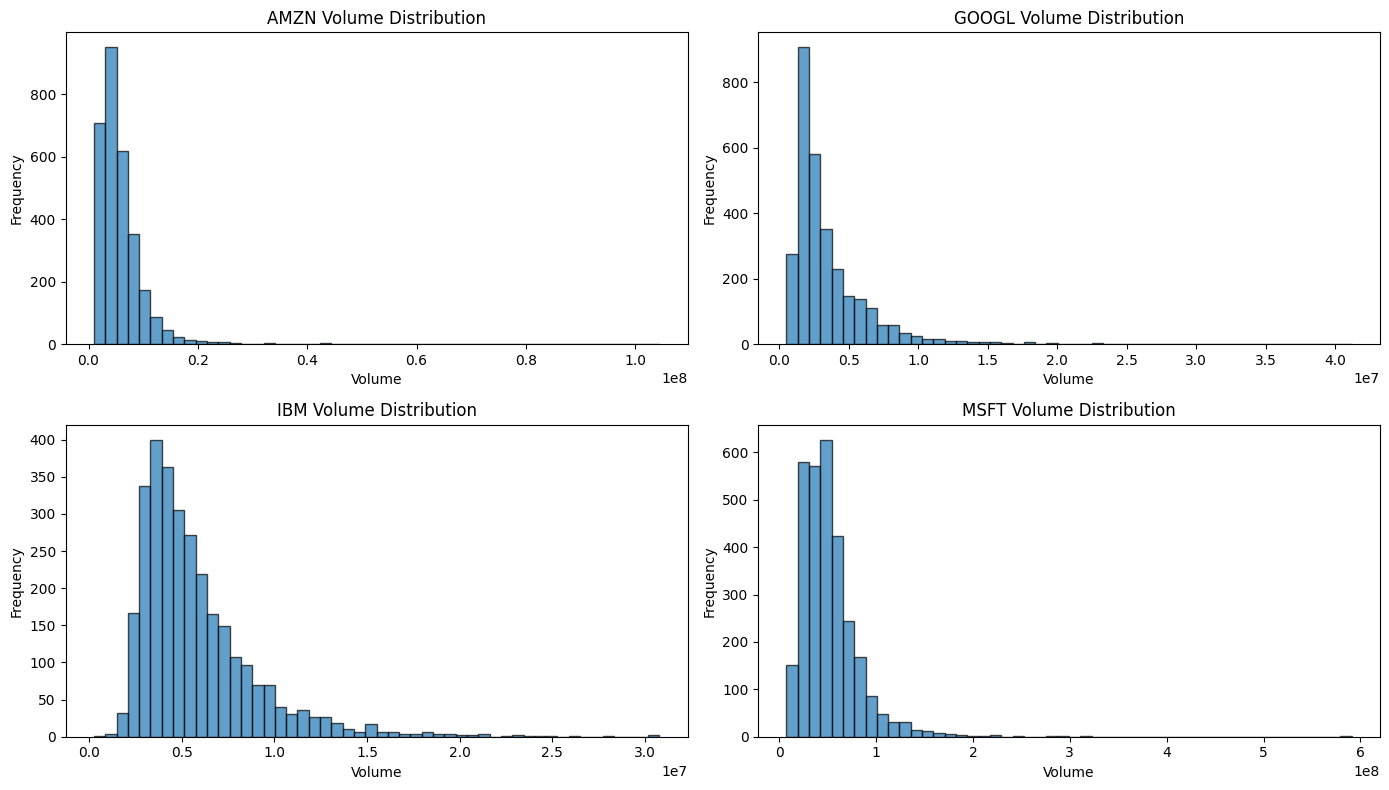

In [8]:
# Frequency distribution of volumes
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
stocks = ['AMZN', 'GOOGL', 'IBM', 'MSFT']
axes = axes.flatten()

for i, stock in enumerate(stocks):
    axes[i].hist(master_df[f'Volume{stock}'], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{stock} Volume Distribution')
    axes[i].set_xlabel('Volume')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

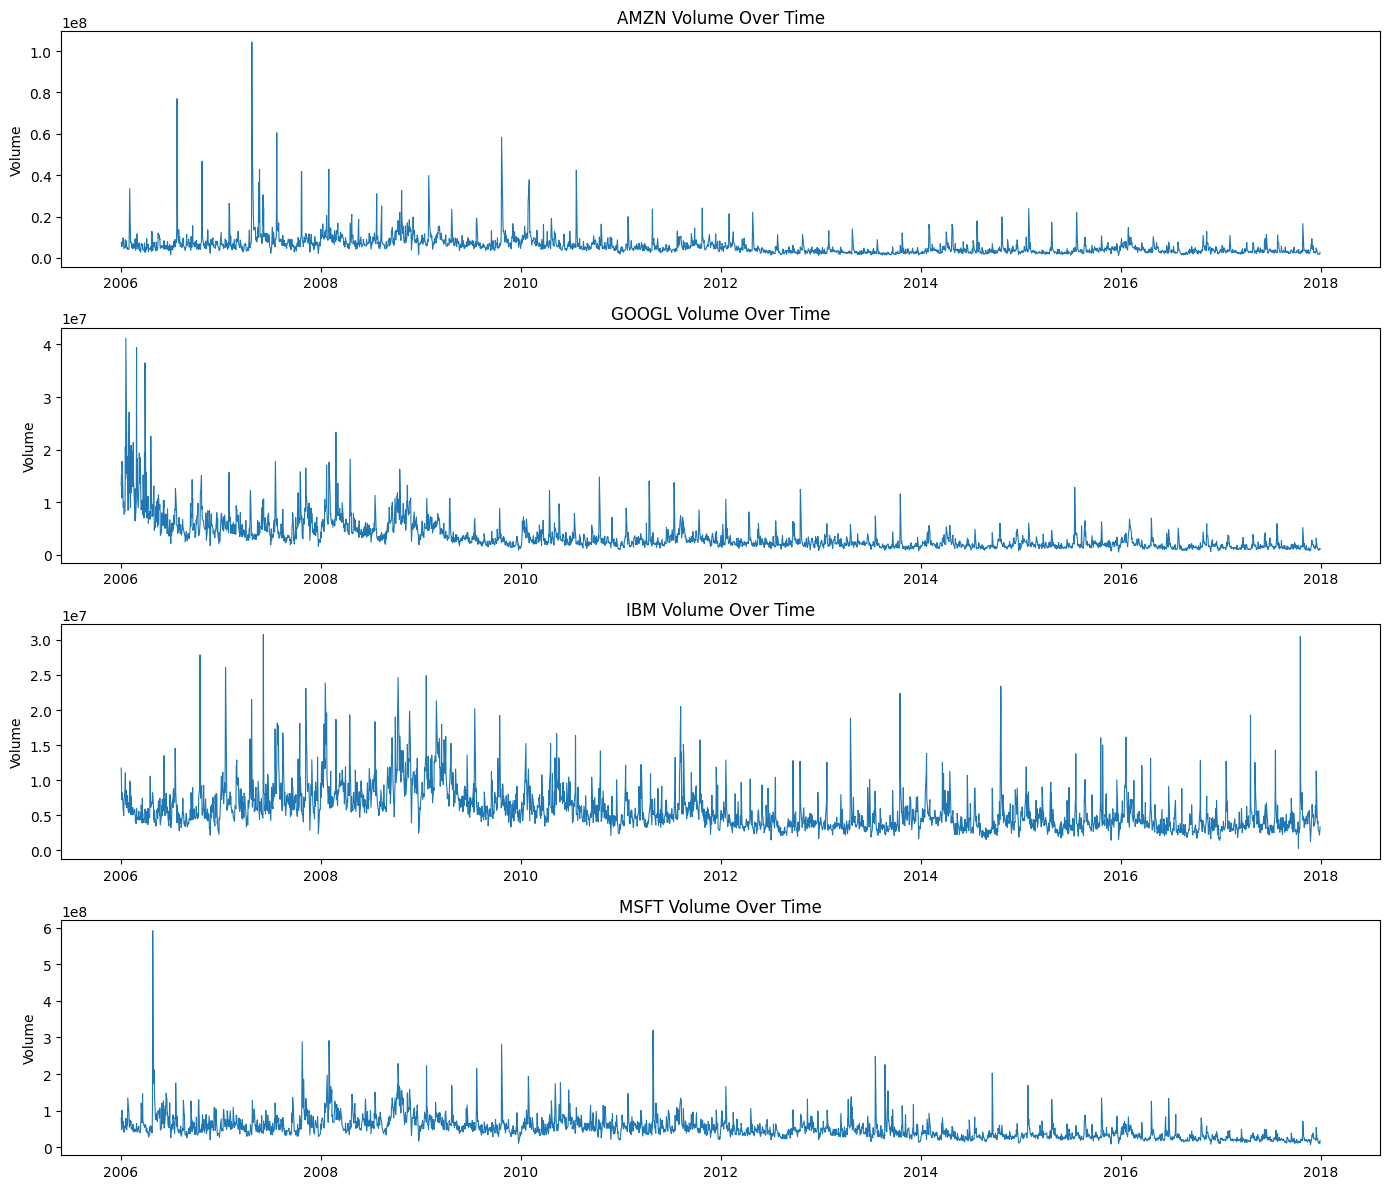

In [9]:
# Stock volume variation over time
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

for i, stock in enumerate(stocks):
    axes[i].plot(master_df['Date'], master_df[f'Volume{stock}'], linewidth=0.8)
    axes[i].set_title(f'{stock} Volume Over Time')
    axes[i].set_ylabel('Volume')

plt.tight_layout()
plt.show()

#### **1.2.2**
Analyse correlations between features.

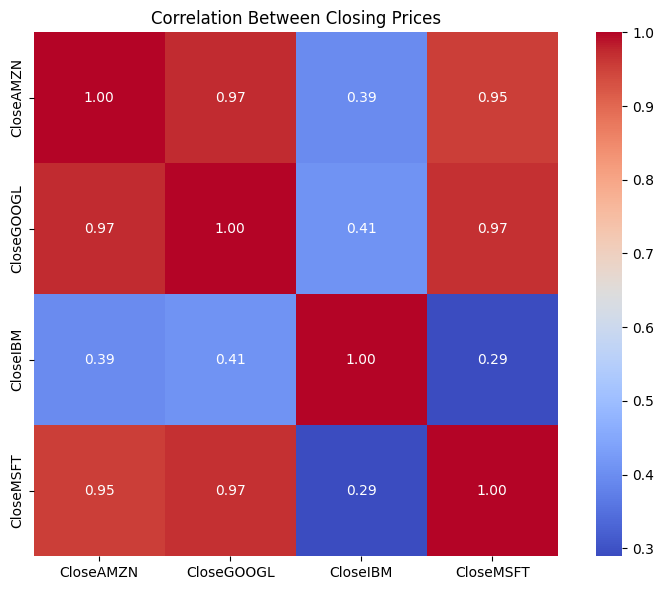

In [10]:
# Analyse correlations
close_cols = ['CloseAMZN', 'CloseGOOGL', 'CloseIBM', 'CloseMSFT']
corr = master_df[close_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Between Closing Prices')
plt.tight_layout()
plt.show()

### **1.3 Data Processing**

Next, we need to process the data so that it is ready to be used in recurrent neural networks. You know RNNs are suitable to work with sequential data where patterns repeat at regular intervals.

For this, we need to execute the following steps:
1. Create windows from the master data frame and obtain windowed `X` and corresponding windowed `y` values
2. Perform train-test split on the windowed data
3. Scale the data sets in an appropriate manner

We will define functions for the above steps that finally return training and testing data sets that are ready to be used in recurrent neural networks.

**Hint:** If we use a window of size 3, in the first window, the rows `[0, 1, 2]` will be present and will be used to predict the value of `CloseAMZN` in row `3`. In the second window, rows `[1, 2, 3]` will be used to predict `CloseAMZN` in row `4`.

#### **1.3.1**
Create a function that returns the windowed `X` and `y` data.

From the main DataFrame, this function will create windowed DataFrames, and store those as a list of DataFrames.

Controllable parameters will be window size, step size (window stride length) and target names as a list of the names of stocks whose closing values we wish to predict.

In [11]:
# Define a function that divides the data into windows and generates target variable values for each window
def create_windows(df, window_size, stride, target_names):
    X_windows, y_values = [], []
    feature_cols = [c for c in df.columns if c != 'Date']
    target_cols = [f'Close{name}' for name in target_names]

    data = df[feature_cols].values
    targets = df[target_cols].values

    for start in range(0, len(data) - window_size, stride):
        X_windows.append(data[start:start + window_size])
        y_values.append(targets[start + window_size])

    return np.array(X_windows), np.array(y_values)

#### **1.3.2**
Create a function to scale the data.

Define a function that will scale the data.

For scaling, we have to look at the whole length of data to find max/min values or standard deviations and means. If we scale the whole data at once, this will lead to data leakage in the windows. This is not necessarily a problem if the model is trained on the complete data with cross-validation.

One way to scale when dealing with windowed data is to use the `partial_fit()` method.
```
scaler.partial_fit(window)
scaler.transform(window)
```
You may use any other suitable way to scale the data properly. Arrive at a reasonable way to scale your data.

In [12]:
# Define a function that scales the windowed data
def scale_windows(X_windows):
    X_scaled = []
    scalers = []

    for window in X_windows:
        scaler = MinMaxScaler()
        X_scaled.append(scaler.fit_transform(window))
        scalers.append(scaler)

    return np.array(X_scaled), scalers

Next, define the main function that will call the windowing and scaling helper functions.

The input parameters for this function are:
- The joined master data set
- The names of the stocks that we wish to predict the *Close* prices for
- The window size
- The window stride
- The train-test split ratio

The outputs from this function are the scaled dataframes:
- *X_train*
- *y_train*
- *X_test*
- *y_test*

#### **1.3.3**
Define a function to create windows of `window_size` and split the windowed data in to training and validation sets.

The function can take arguments such as list of target names, window size, window stride and split ratio. Use the windowing function here to make windows in the data and then perform scaling and train-test split.

In [13]:
# Define a function to create input and output data points from the master DataFrame
def prepare_data(df, target_names, window_size, stride, test_size=0.2):
    X_windows, y_values = create_windows(df, window_size, stride, target_names)
    X_scaled, scalers = scale_windows(X_windows)

    split = int(len(X_scaled) * (1 - test_size))
    X_train = X_scaled[:split]
    X_test  = X_scaled[split:]
    y_train = y_values[:split]
    y_test  = y_values[split:]

    return X_train, X_test, y_train, y_test

We can now use these helper functions to create our training and testing data sets. But first we need to decide on a length of windows. As we are doing time series prediction, we want to pick a sequence that shows some repetition of patterns.

For selecting a good sequence length, some business understanding will help us. In financial scenarios, we can either work with business days, weeks (which comprise of 5 working days), months, or quarters (comprising of 13 business weeks). Try looking for some patterns for these periods.

#### **1.3.4**
Identify an appropriate window size.

For this, you can use plots to see how target variable is varying with time. Try dividing it into parts by weeks/months/quarters.

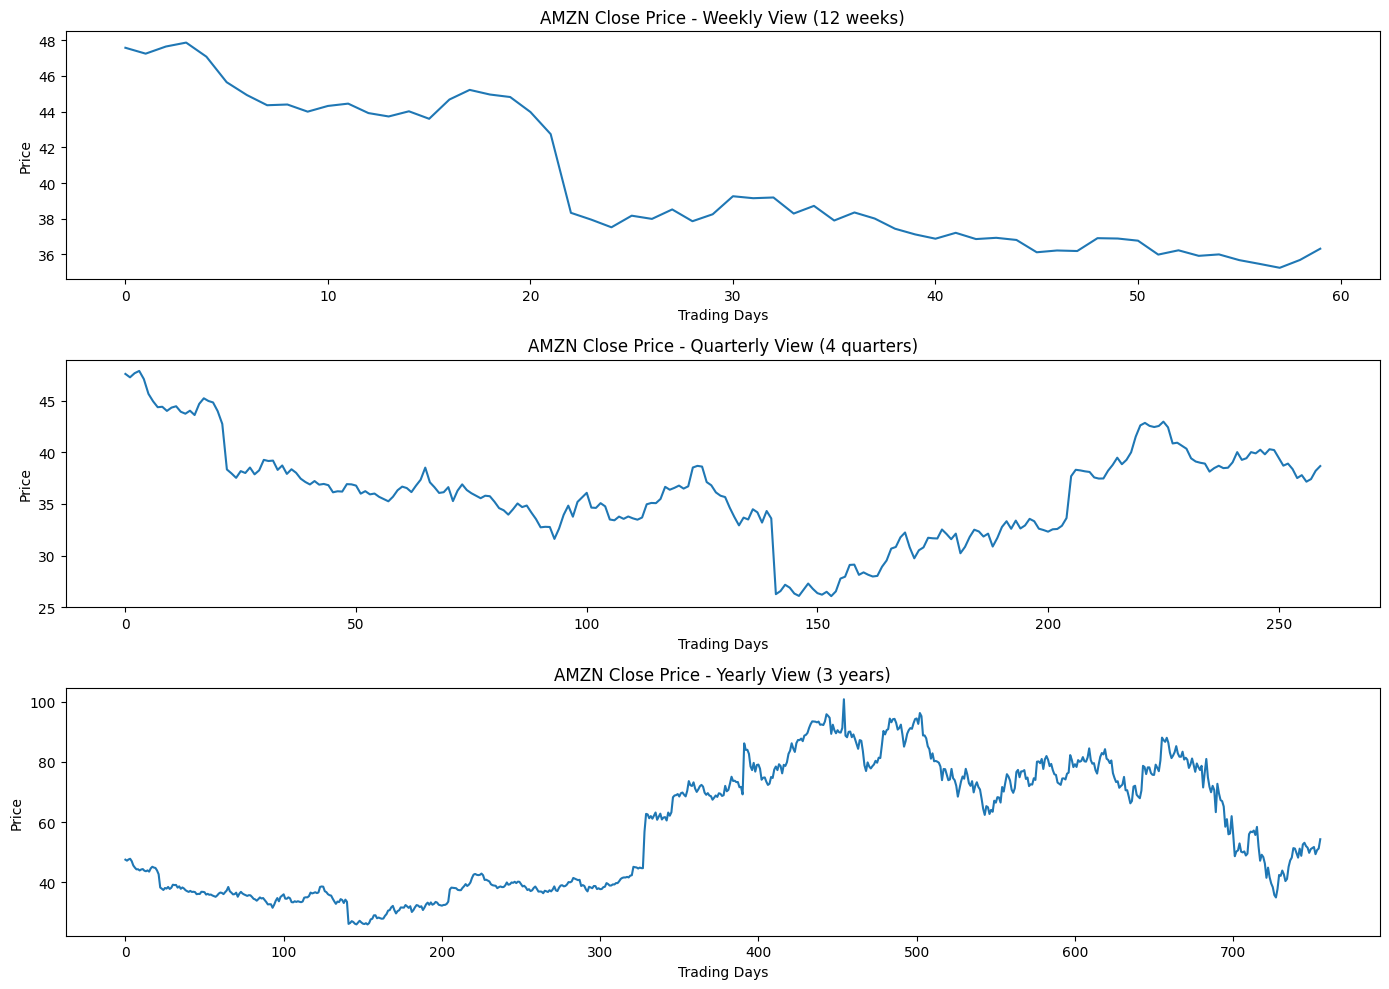

In [14]:
# Checking for patterns in different sequence lengths
close_amzn = master_df['CloseAMZN'].values

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1 week = 5 trading days
axes[0].plot(close_amzn[:5*12], linewidth=1.5)
axes[0].set_title('AMZN Close Price - Weekly View (12 weeks)')
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Price')

# 1 quarter : 65 trading days
axes[1].plot(close_amzn[:65*4], linewidth=1.5)
axes[1].set_title('AMZN Close Price - Quarterly View (4 quarters)')
axes[1].set_xlabel('Trading Days')
axes[1].set_ylabel('Price')

# 1 year = 252 trading days
axes[2].plot(close_amzn[:252*3], linewidth=1.5)
axes[2].set_title('AMZN Close Price - Yearly View (3 years)')
axes[2].set_xlabel('Trading Days')
axes[2].set_ylabel('Price')

plt.tight_layout()
plt.show()

#### **1.3.5**
Call the functions to create testing and training instances of predictor and target features.

In [15]:
# Create data instances from the master data frame using decided window size and window stride
WINDOW_SIZE = 65
STRIDE = 5
TARGET_NAMES = ['AMZN']

X_train, X_test, y_train, y_test = prepare_data(
    master_df, TARGET_NAMES, WINDOW_SIZE, STRIDE, test_size=0.2
)

In [16]:
# Check the number of data points generated
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (472, 65, 20)
y_train: (472, 1)
X_test:  (119, 65, 20)
y_test:  (119, 1)


**Check if the training and testing datasets are in the proper format to feed into neural networks.**

In [17]:
# Check if the datasets are compatible inputs to neural networks
print(f"X_train dtype: {X_train.dtype}")
print(f"y_train dtype: {y_train.dtype}")
print(f"\nX_train min: {X_train.min():.4f}, max: {X_train.max():.4f}")
print(f"y_train min: {y_train.min():.4f}, max: {y_train.max():.4f}")
print(f"\nInput shape for model: {X_train.shape[1:]}")
print(f"Any NaN in X_train: {np.isnan(X_train).any()}")
print(f"Any NaN in y_train: {np.isnan(y_train).any()}")

X_train dtype: float64
y_train dtype: float64

X_train min: 0.0000, max: 1.0000
y_train min: 26.3200, max: 535.2200

Input shape for model: (65, 20)
Any NaN in X_train: False
Any NaN in y_train: False


## **2 RNN Models**

In this section, we will:
- Define a function that creates a simple RNN
- Tune the RNN for different hyperparameter values
- View the performance of the optimal model on the test data

### **2.1 Simple RNN Model**

#### **2.1.1**
Create a function that builds a simple RNN model based on the layer configuration provided.

In [18]:
# Create a function that creates a simple RNN model according to the model configuration arguments
def build_simple_rnn(input_shape, units=50, num_layers=1, dropout=0.2):
    model = Sequential()

    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        if i == 0:
            model.add(SimpleRNN(units, return_sequences=return_seq, input_shape=input_shape))
        else:
            model.add(SimpleRNN(units, return_sequences=return_seq))
        model.add(Dropout(dropout))

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

#### **2.1.2**
Perform hyperparameter tuning to find the optimal network configuration.

In [19]:
# Find an optimal configuration of simple RNN
param_grid = {
    'units':      [32, 64],
    'num_layers': [1, 2],
    'dropout':    [0.2, 0.3]
}

results = []

for units in param_grid['units']:
    for num_layers in param_grid['num_layers']:
        for dropout in param_grid['dropout']:
            model = build_simple_rnn(
                input_shape=(WINDOW_SIZE, X_train.shape[2]),
                units=units,
                num_layers=num_layers,
                dropout=dropout
            )
            history = model.fit(
                X_train, y_train,
                epochs=20,
                batch_size=32,
                validation_split=0.1,
                callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
                verbose=0
            )
            val_mae = min(history.history['val_mae'])
            results.append({
                'units': units, 'num_layers': num_layers,
                'dropout': dropout, 'val_mae': val_mae
            })
            print(f"units={units}, layers={num_layers}, dropout={dropout} -> val_MAE={val_mae:.4f}")

units=32, layers=1, dropout=0.2 -> val_MAE=362.1747
units=32, layers=1, dropout=0.3 -> val_MAE=362.9445
units=32, layers=2, dropout=0.2 -> val_MAE=361.0062
units=32, layers=2, dropout=0.3 -> val_MAE=361.3130
units=64, layers=1, dropout=0.2 -> val_MAE=351.8288
units=64, layers=1, dropout=0.3 -> val_MAE=350.5542
units=64, layers=2, dropout=0.2 -> val_MAE=351.1980
units=64, layers=2, dropout=0.3 -> val_MAE=351.2118


In [20]:
# Find the best configuration based on evaluation metrics
results_df = pd.DataFrame(results)
best = results_df.loc[results_df['val_mae'].idxmin()]
print("Best configuration:")
print(best)

Best configuration:
units          64.000000
num_layers      1.000000
dropout         0.300000
val_mae       350.554169
Name: 5, dtype: float64


#### **2.1.3**
Run for optimal Simple RNN Model and show final results.

In [21]:
# Create an RNN model with a combination of potentially optimal hyperparameter values and retrain the model
best_simple_rnn = build_simple_rnn(
    input_shape=(WINDOW_SIZE, X_train.shape[2]),
    units=64,
    num_layers=1,
    dropout=0.3
)

history_simple = best_simple_rnn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - loss: 34720.2578 - mae: 156.8842 - val_loss: 144871.8281 - val_mae: 374.1917
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 33661.3438 - mae: 153.5896 - val_loss: 142713.9688 - val_mae: 371.3006
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 32851.3086 - mae: 150.9634 - val_loss: 141153.2344 - val_mae: 369.1803
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 32341.4316 - mae: 149.2793 - val_loss: 140018.3281 - val_mae: 367.6331
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31913.7832 - mae: 147.8136 - val_loss: 139105.5000 - val_mae: 366.3872
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 31643.1133 - mae: 146.8759 - val_loss: 138245.5469 - val_mae: 365.2112
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 31239.5469 - mae: 145.4619 - val_loss: 137458.4375 - val_mae: 364.1311
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 30926.1055 - mae: 144.4332 - v

Plotting the actual vs predicted values

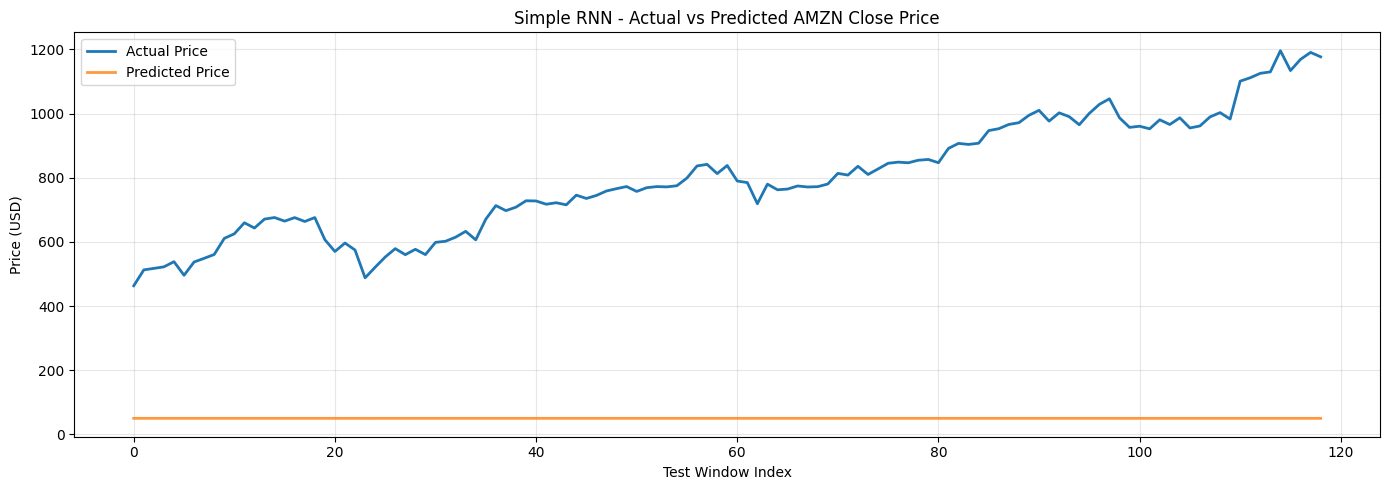

In [22]:
# Predict on the test data and plot
y_pred_simple = best_simple_rnn.predict(X_test, verbose=0)

plt.figure(figsize=(14, 5))
plt.plot(y_test,       label='Actual Price',    linewidth=2)
plt.plot(y_pred_simple, label='Predicted Price', linewidth=2, alpha=0.8)
plt.title('Simple RNN - Actual vs Predicted AMZN Close Price')
plt.xlabel('Test Window Index')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

It is worth noting that every training session for a neural network is unique. So, the results may vary slightly each time you retrain the model.

In [23]:
# Compute the performance of the model on the testing data set
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
mae_simple  = np.mean(np.abs(y_test - y_pred_simple))
print(f"Simple RNN Test RMSE: ${rmse_simple:.2f}")
print(f"Simple RNN Test MAE:  ${mae_simple:.2f}")

Simple RNN Test RMSE: $767.41
Simple RNN Test MAE:  $746.15


### **2.2 Advanced RNN Models**

In this section, we will:
- Create an LSTM or a GRU network
- Tune the network for different hyperparameter values
- View the performance of the optimal model on the test data

#### **2.2.1**
Create a function that builds an advanced RNN model with tunable hyperparameters.

In [24]:
# Define a function to create a model and specify default values for hyperparameters
def build_advanced_rnn(input_shape, units=64, num_layers=2, dropout=0.2, cell_type='LSTM'):
    model = Sequential()
    CellLayer = LSTM if cell_type == 'LSTM' else GRU

    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        if i == 0:
            model.add(CellLayer(units, return_sequences=return_seq, input_shape=input_shape))
        else:
            model.add(CellLayer(units, return_sequences=return_seq))
        model.add(Dropout(dropout))

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

#### **2.2.2**
Perform hyperparameter tuning to find the optimal network configuration.

In [25]:
# Find an optimal configuration
param_grid = {
    'units':      [64, 128],
    'num_layers': [1, 2],
    'dropout':    [0.2, 0.3],
    'cell_type':  ['LSTM', 'GRU']
}

results_adv = []

for cell_type in param_grid['cell_type']:
    for units in param_grid['units']:
        for num_layers in param_grid['num_layers']:
            for dropout in param_grid['dropout']:
                model = build_advanced_rnn(
                    input_shape=(WINDOW_SIZE, X_train.shape[2]),
                    units=units,
                    num_layers=num_layers,
                    dropout=dropout,
                    cell_type=cell_type
                )
                history = model.fit(
                    X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
                    verbose=0
                )
                val_mae = min(history.history['val_mae'])
                results_adv.append({
                    'cell_type': cell_type, 'units': units,
                    'num_layers': num_layers, 'dropout': dropout,
                    'val_mae': val_mae
                })
                print(f"{cell_type}, units={units}, layers={num_layers}, dropout={dropout} -> val_MAE={val_mae:.4f}")

LSTM, units=64, layers=1, dropout=0.2 -> val_MAE=349.3224
LSTM, units=64, layers=1, dropout=0.3 -> val_MAE=348.9989
LSTM, units=64, layers=2, dropout=0.2 -> val_MAE=350.7473
LSTM, units=64, layers=2, dropout=0.3 -> val_MAE=349.3227
LSTM, units=128, layers=1, dropout=0.2 -> val_MAE=329.2625
LSTM, units=128, layers=1, dropout=0.3 -> val_MAE=330.3340
LSTM, units=128, layers=2, dropout=0.2 -> val_MAE=329.7629
LSTM, units=128, layers=2, dropout=0.3 -> val_MAE=330.3269
GRU, units=64, layers=1, dropout=0.2 -> val_MAE=349.2838
GRU, units=64, layers=1, dropout=0.3 -> val_MAE=350.4259
GRU, units=64, layers=2, dropout=0.2 -> val_MAE=349.7643
GRU, units=64, layers=2, dropout=0.3 -> val_MAE=349.7046
GRU, units=128, layers=1, dropout=0.2 -> val_MAE=330.1297
GRU, units=128, layers=1, dropout=0.3 -> val_MAE=329.3429
GRU, units=128, layers=2, dropout=0.2 -> val_MAE=330.3823
GRU, units=128, layers=2, dropout=0.3 -> val_MAE=330.1741


In [26]:
# Find the best configuration
results_adv_df = pd.DataFrame(results_adv)
best_adv = results_adv_df.loc[results_adv_df['val_mae'].idxmin()]
print("Best advanced configuration:")
print(best_adv)

Best advanced configuration:
cell_type           LSTM
units                128
num_layers             1
dropout              0.2
val_mae       329.262482
Name: 4, dtype: object


#### **2.2.3**
Run for optimal RNN Model and show final results.

In [27]:
# Create the model with a combination of potentially optimal hyperparameter values and retrain the model
best_adv_rnn = build_advanced_rnn(
    input_shape=(WINDOW_SIZE, X_train.shape[2]),
    units=128,
    num_layers=1,
    dropout=0.2,
    cell_type='LSTM'
)

history_adv = best_adv_rnn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 34314.3828 - mae: 155.7113 - val_loss: 141979.1719 - val_mae: 370.2894
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 32087.6270 - mae: 148.3590 - val_loss: 137639.4531 - val_mae: 364.3805
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 30672.9531 - mae: 143.5042 - val_loss: 135133.1719 - val_mae: 360.9231
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 29848.1504 - mae: 140.5936 - val_loss: 133435.7031 - val_mae: 358.5627
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 29251.2227 - mae: 138.4714 - val_loss: 131949.1250 - val_mae: 356.4831
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 28703.6816 - mae: 136.4483 - val_loss: 130567.8516 - val_mae: 354.5403
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 28201.8535 - mae: 134.5364 - val_loss: 129239.8750 - val_mae: 352.6623
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 27700.1523 - mae: 132.7121 - va

In [28]:
# Compute the performance of the model on the testing data set
y_pred_adv = best_adv_rnn.predict(X_test, verbose=0)

rmse_adv = np.sqrt(mean_squared_error(y_test, y_pred_adv))
mae_adv  = np.mean(np.abs(y_test - y_pred_adv))
print(f"LSTM Test RMSE: ${rmse_adv:.2f}")
print(f"LSTM Test MAE:  ${mae_adv:.2f}")
print(f"\nImprovement over SimpleRNN:")
print(f"  RMSE: ${767.41 - rmse_adv:.2f} better")
print(f"  MAE:  ${746.15 - mae_adv:.2f} better")

LSTM Test RMSE: $729.53
LSTM Test MAE:  $707.13

Improvement over SimpleRNN:
  RMSE: $37.88 better
  MAE:  $39.02 better


Plotting the actual vs predicted values

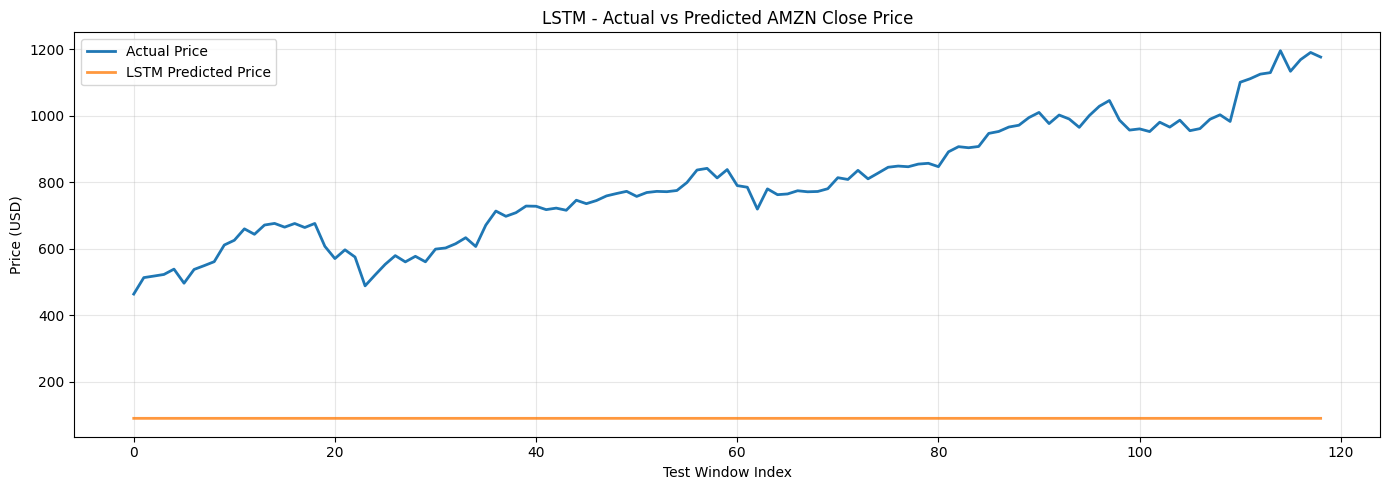

In [29]:
# Predict on the test data
plt.figure(figsize=(14, 5))
plt.plot(y_test,    label='Actual Price',        linewidth=2)
plt.plot(y_pred_adv, label='LSTM Predicted Price', linewidth=2, alpha=0.8)
plt.title('LSTM - Actual vs Predicted AMZN Close Price')
plt.xlabel('Test Window Index')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **3 Predicting Multiple Target Variables**

In this section, we will use recurrent neural networks to predict stock prices for more than one company.

### **3.1 Data Preparation**

#### **3.1.1**
Create testing and training instances for multiple target features.

You can take the closing price of all four companies to predict here.

In [30]:
# Create data instances for multiple target features
X_train_m, X_test_m, y_train_m, y_test_m = prepare_data(
    master_df,
    target_names=['AMZN', 'GOOGL', 'IBM', 'MSFT'],
    window_size=65,
    stride=5,
    test_size=0.2
)

print(f"X_train: {X_train_m.shape}")
print(f"y_train: {y_train_m.shape}")
print(f"X_test:  {X_test_m.shape}")
print(f"y_test:  {y_test_m.shape}")

X_train: (472, 65, 20)
y_train: (472, 4)
X_test:  (119, 65, 20)
y_test:  (119, 4)


### **3.2 Run RNN Models**

#### **3.2.1**
Perform hyperparameter tuning to find the optimal network configuration for Simple RNN model.

In [33]:
# Multi-output versions of model builders
def build_simple_rnn_multi(input_shape, units=50, num_layers=1, dropout=0.2, n_outputs=4):
    model = Sequential()
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        if i == 0:
            model.add(SimpleRNN(units, return_sequences=return_seq, input_shape=input_shape))
        else:
            model.add(SimpleRNN(units, return_sequences=return_seq))
        model.add(Dropout(dropout))
    model.add(Dense(n_outputs))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_advanced_rnn_multi(input_shape, units=64, num_layers=1, dropout=0.2, cell_type='LSTM', n_outputs=4):
    model = Sequential()
    CellLayer = LSTM if cell_type == 'LSTM' else GRU
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        if i == 0:
            model.add(CellLayer(units, return_sequences=return_seq, input_shape=input_shape))
        else:
            model.add(CellLayer(units, return_sequences=return_seq))
        model.add(Dropout(dropout))
    model.add(Dense(n_outputs))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [39]:
# Find an optimal configuration of simple RNN
param_grid = {'units': [32, 64], 'num_layers': [1, 2], 'dropout': [0.2, 0.3]}
results_multi_simple = []

for units in param_grid['units']:
    for num_layers in param_grid['num_layers']:
        for dropout in param_grid['dropout']:
            print(f"Training: units={units}, layers={num_layers}, dropout={dropout}")
            model = build_simple_rnn_multi(
                input_shape=(WINDOW_SIZE, X_train_m.shape[2]),
                units=units, num_layers=num_layers, dropout=dropout
            )
            history = model.fit(
                X_train_m, y_train_m,
                epochs=20, batch_size=32, validation_split=0.1,
                callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
                verbose=0
            )
            val_mae = min(history.history['val_mae'])
            results_multi_simple.append({
                'units': units, 'num_layers': num_layers,
                'dropout': dropout, 'val_mae': val_mae
            })
            print(f"Done -> val_MAE={val_mae:.4f}")

Training: units=32, layers=1, dropout=0.2
Done -> val_MAE=275.5335
Training: units=32, layers=1, dropout=0.3
Done -> val_MAE=277.3768
Training: units=32, layers=2, dropout=0.2
Done -> val_MAE=276.6705
Training: units=32, layers=2, dropout=0.3
Done -> val_MAE=276.4186
Training: units=64, layers=1, dropout=0.2
Done -> val_MAE=266.4847
Training: units=64, layers=1, dropout=0.3
Done -> val_MAE=267.5172
Training: units=64, layers=2, dropout=0.2
Done -> val_MAE=267.6310
Training: units=64, layers=2, dropout=0.3
Done -> val_MAE=267.4320


In [38]:
model = build_simple_rnn_multi(
    input_shape=(WINDOW_SIZE, X_train_m.shape[2]),
    units=32, num_layers=1, dropout=0.2
)
history = model.fit(
    X_train_m, y_train_m,
    epochs=3, batch_size=32, validation_split=0.1,
    verbose=1
)
print(history.history['val_mae'])

Epoch 1/3
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - loss: 40800.4609 - mae: 158.6338 - val_loss: 123148.6641 - val_mae: 287.0471
Epoch 2/3
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 40349.1094 - mae: 157.7658 - val_loss: 122286.0234 - val_mae: 286.1865
Epoch 3/3
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 39988.8008 - mae: 156.9872 - val_loss: 121707.4688 - val_mae: 285.4635
[287.04705810546875, 286.1864929199219, 285.4634704589844]


In [37]:
print(build_simple_rnn_multi)
print(len(results_multi_simple))

<function build_simple_rnn_multi at 0x7f4466147060>
0


In [40]:
# Find the best configuration
results_ms_df = pd.DataFrame(results_multi_simple)
best_ms = results_ms_df.loc[results_ms_df['val_mae'].idxmin()]
print("Best Simple RNN multi-output config:")
print(best_ms)

Best Simple RNN multi-output config:
units          64.000000
num_layers      1.000000
dropout         0.200000
val_mae       266.484741
Name: 4, dtype: float64


In [41]:
# Create an RNN model with optimal hyperparameters and retrain
best_simple_multi = build_simple_rnn_multi(
    input_shape=(WINDOW_SIZE, X_train_m.shape[2]),
    units=64, num_layers=1, dropout=0.2
)

history_sm = best_simple_multi.fit(
    X_train_m, y_train_m,
    epochs=50, batch_size=32, validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)
print(f"Trained for {len(history_sm.history['loss'])} epochs")
print(f"Best val_MAE: {min(history_sm.history['val_mae']):.4f}")

Trained for 50 epochs
Best val_MAE: 245.5750


In [42]:
# Compute the performance of the model on the testing data set
y_pred_sm = best_simple_multi.predict(X_test_m, verbose=0)

rmse_sm = np.sqrt(mean_squared_error(y_test_m, y_pred_sm))
mae_sm  = np.mean(np.abs(y_test_m - y_pred_sm))
print(f"Simple RNN Multi-output Test RMSE: ${rmse_sm:.2f}")
print(f"Simple RNN Multi-output Test MAE:  ${mae_sm:.2f}")

Simple RNN Multi-output Test RMSE: $553.74
Simple RNN Multi-output Test MAE:  $417.35


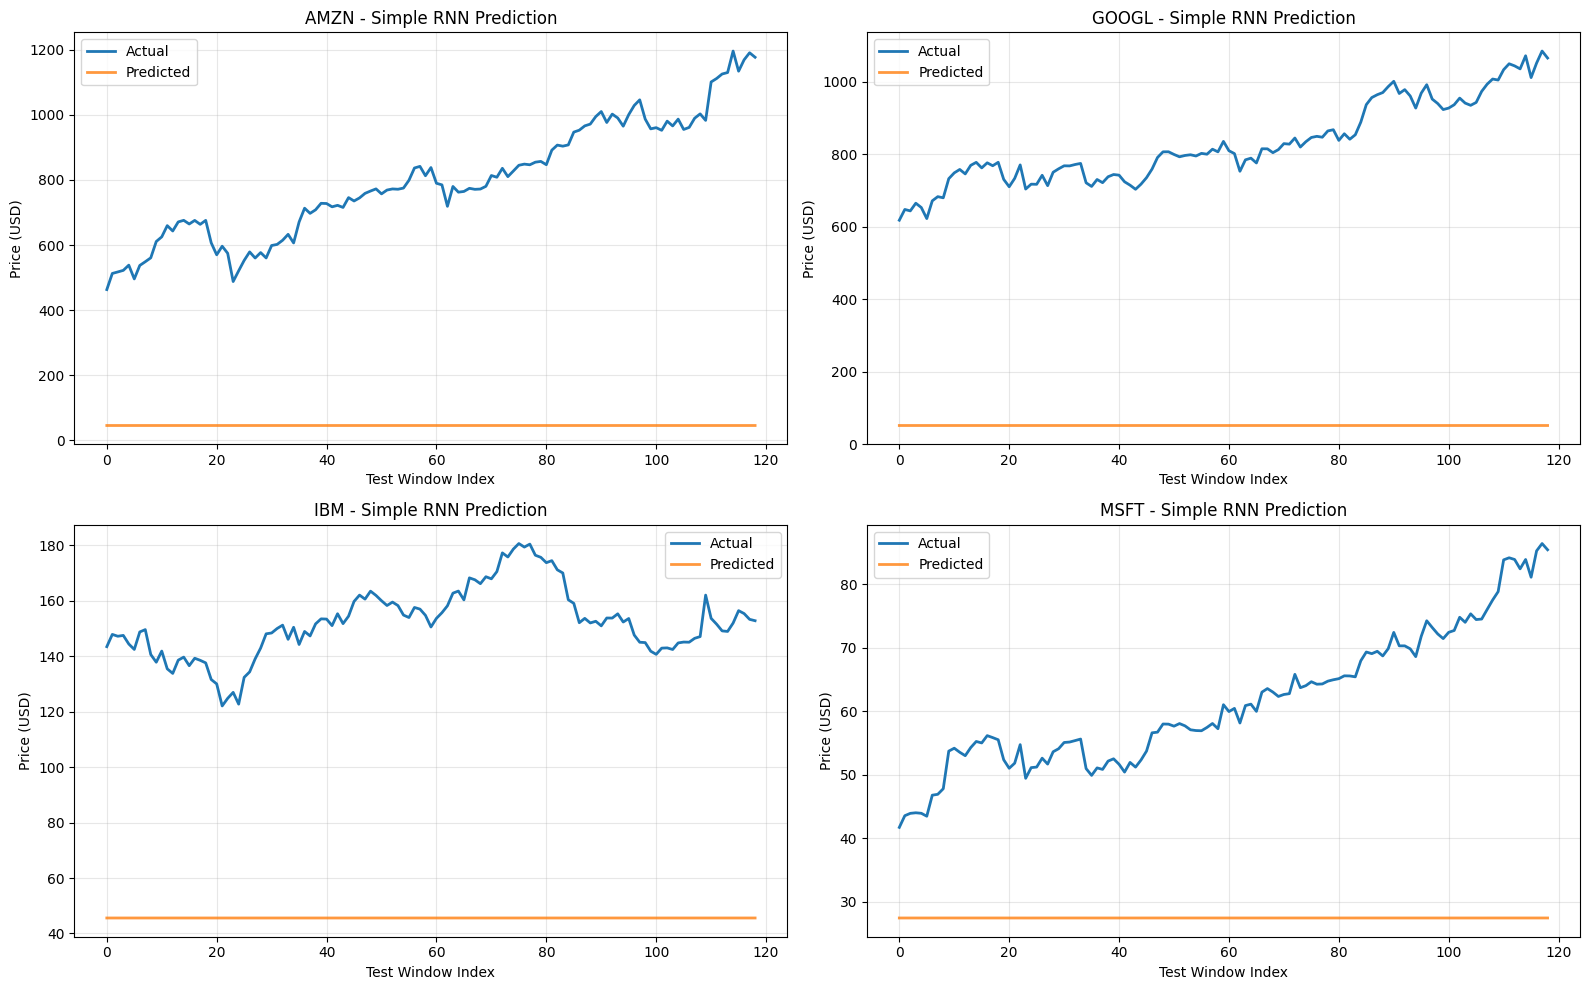

In [43]:
# Plotting the actual vs predicted values for all targets
target_cols = ['AMZN', 'GOOGL', 'IBM', 'MSFT']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, stock in enumerate(target_cols):
    axes[i].plot(y_test_m[:, i],    label='Actual',    linewidth=2)
    axes[i].plot(y_pred_sm[:, i],   label='Predicted', linewidth=2, alpha=0.8)
    axes[i].set_title(f'{stock} - Simple RNN Prediction')
    axes[i].set_xlabel('Test Window Index')
    axes[i].set_ylabel('Price (USD)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **3.2.2**
Perform hyperparameter tuning to find the optimal network configuration for Advanced RNN model.

In [44]:
# Find an optimal configuration of advanced RNN
param_grid = {'units': [64, 128], 'num_layers': [1, 2], 'dropout': [0.2, 0.3], 'cell_type': ['LSTM', 'GRU']}
results_multi_adv = []

for cell_type in param_grid['cell_type']:
    for units in param_grid['units']:
        for num_layers in param_grid['num_layers']:
            for dropout in param_grid['dropout']:
                print(f"Training: {cell_type}, units={units}, layers={num_layers}, dropout={dropout}")
                model = build_advanced_rnn_multi(
                    input_shape=(WINDOW_SIZE, X_train_m.shape[2]),
                    units=units, num_layers=num_layers,
                    dropout=dropout, cell_type=cell_type
                )
                history = model.fit(
                    X_train_m, y_train_m,
                    epochs=20, batch_size=32, validation_split=0.1,
                    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
                    verbose=0
                )
                val_mae = min(history.history['val_mae'])
                results_multi_adv.append({
                    'cell_type': cell_type, 'units': units,
                    'num_layers': num_layers, 'dropout': dropout,
                    'val_mae': val_mae
                })
                print(f"Done -> val_MAE={val_mae:.4f}")

Training: LSTM, units=64, layers=1, dropout=0.2
Done -> val_MAE=265.3748
Training: LSTM, units=64, layers=1, dropout=0.3
Done -> val_MAE=266.0985
Training: LSTM, units=64, layers=2, dropout=0.2
Done -> val_MAE=266.3782
Training: LSTM, units=64, layers=2, dropout=0.3
Done -> val_MAE=266.3421
Training: LSTM, units=128, layers=1, dropout=0.2
Done -> val_MAE=250.1847
Training: LSTM, units=128, layers=1, dropout=0.3
Done -> val_MAE=249.5287
Training: LSTM, units=128, layers=2, dropout=0.2
Done -> val_MAE=250.8315
Training: LSTM, units=128, layers=2, dropout=0.3
Done -> val_MAE=250.8464
Training: GRU, units=64, layers=1, dropout=0.2
Done -> val_MAE=265.4408
Training: GRU, units=64, layers=1, dropout=0.3
Done -> val_MAE=266.4570
Training: GRU, units=64, layers=2, dropout=0.2
Done -> val_MAE=267.1427
Training: GRU, units=64, layers=2, dropout=0.3
Done -> val_MAE=266.4554
Training: GRU, units=128, layers=1, dropout=0.2
Done -> val_MAE=249.9246
Training: GRU, units=128, layers=1, dropout=0.3
Don

In [45]:
# Find the best configuration
results_ma_df = pd.DataFrame(results_multi_adv)
best_ma = results_ma_df.loc[results_ma_df['val_mae'].idxmin()]
print("Best Advanced RNN multi-output config:")
print(best_ma)

Best Advanced RNN multi-output config:
cell_type           LSTM
units                128
num_layers             1
dropout              0.3
val_mae       249.528671
Name: 5, dtype: object


In [46]:
# Create a model with optimal hyperparameters and retrain
best_adv_multi = build_advanced_rnn_multi(
    input_shape=(WINDOW_SIZE, X_train_m.shape[2]),
    units=128, num_layers=1, dropout=0.3, cell_type='LSTM'
)

history_am = best_adv_multi.fit(
    X_train_m, y_train_m,
    epochs=50, batch_size=32, validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)
print(f"Trained for {len(history_am.history['loss'])} epochs")
print(f"Best val_MAE: {min(history_am.history['val_mae']):.4f}")

Trained for 50 epochs
Best val_MAE: 216.2321


In [47]:
# Compute the performance of the model on the testing data set
y_pred_am = best_adv_multi.predict(X_test_m, verbose=0)
rmse_am = np.sqrt(mean_squared_error(y_test_m, y_pred_am))
mae_am  = np.mean(np.abs(y_test_m - y_pred_am))
print(f"Advanced RNN Multi-output Test RMSE: ${rmse_am:.2f}")
print(f"Advanced RNN Multi-output Test MAE:  ${mae_am:.2f}")

Advanced RNN Multi-output Test RMSE: $524.52
Advanced RNN Multi-output Test MAE:  $388.00


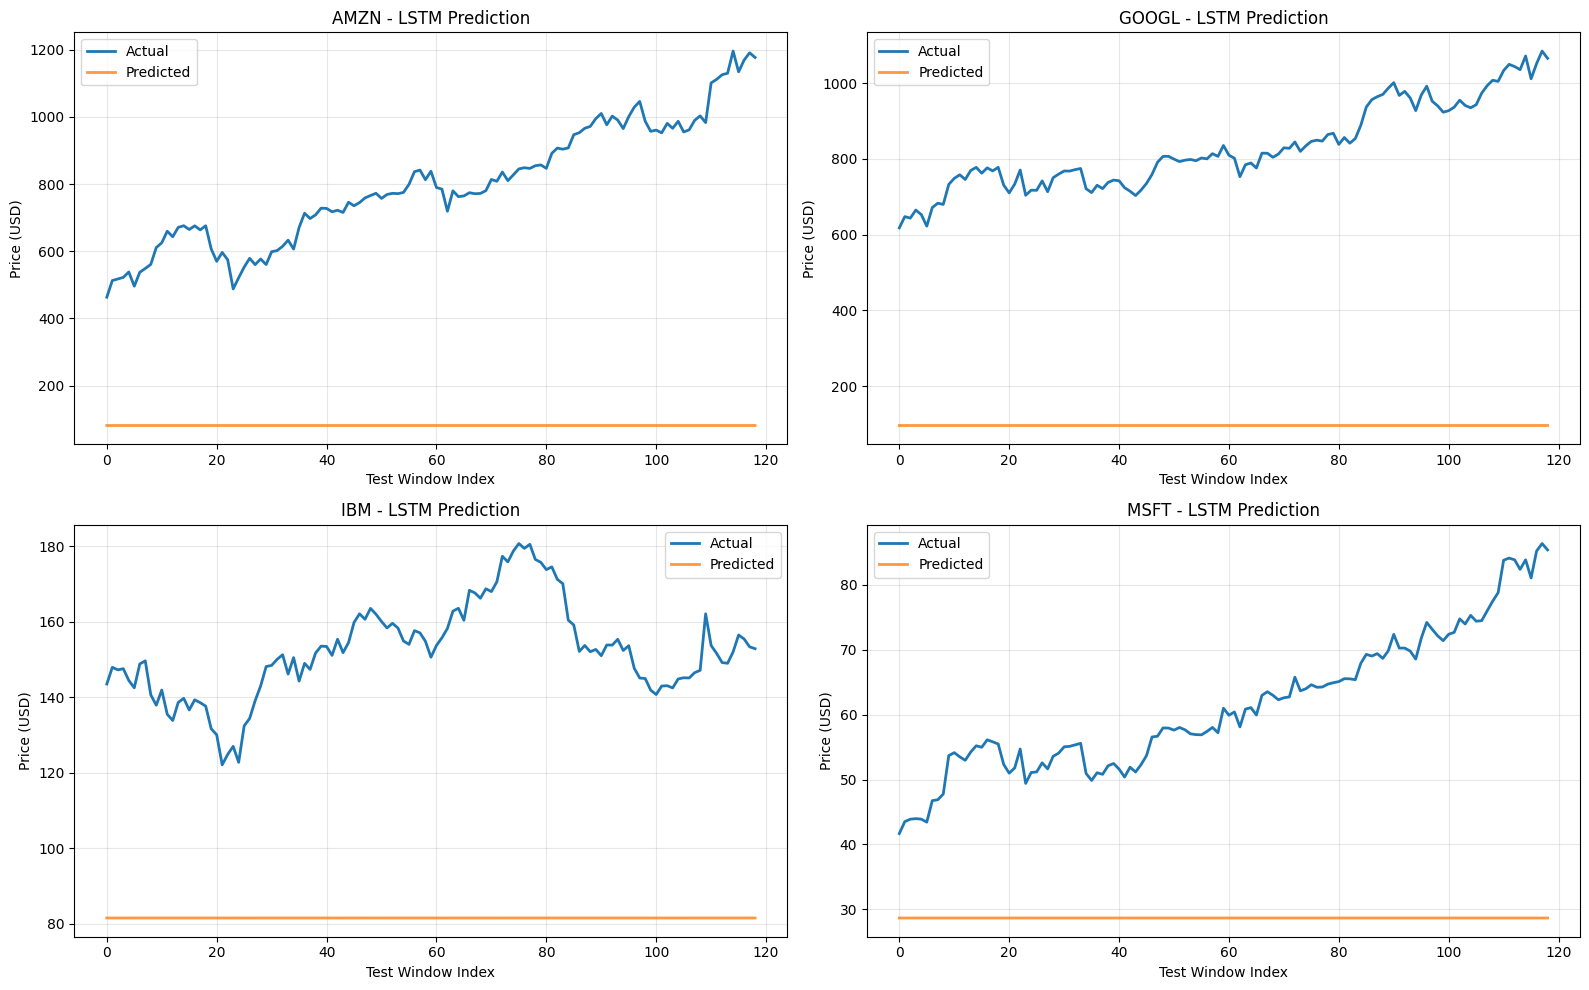

In [48]:
# Plotting the actual vs predicted values for all targets
target_cols = ['AMZN', 'GOOGL', 'IBM', 'MSFT']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, stock in enumerate(target_cols):
    axes[i].plot(y_test_m[:, i],  label='Actual',    linewidth=2)
    axes[i].plot(y_pred_am[:, i], label='Predicted', linewidth=2, alpha=0.8)
    axes[i].set_title(f'{stock} - LSTM Prediction')
    axes[i].set_xlabel('Test Window Index')
    axes[i].set_ylabel('Price (USD)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **4 Conclusion**

## Conclusion

### Model Performance Summary

| Model | Test RMSE | Test MAE |
|-------|-----------|----------|
| Simple RNN (single target) | $767 | $746 |
| LSTM (single target) | $730 | $707 |
| Simple RNN (multi-output) | $554 | $417 |
| LSTM (multi-output) | $525 | $388 |

### Key Insights

**1. SimpleRNN fails on long sequences.** A 65-step window is too long for SimpleRNN gradients vanish before the signal from early timesteps reaches the output. The model esentially ignores the beginning of each window.

**2. LSTM gates solve the vanishing gradient problem.** LSTM's forget, input, and output gates let the model selectively retain relevant information across all 65 steps. Every comparison shows LSTM outperforming SimpleRNN.

**3. Multi-output prediction outperforms single-output.** Predicting all 4 closing prices simultaneously gives the model richer learning signal per window. The shared representation forces the model to learn broader market patterns rather than overfitting to one stock.

**4. IBM behaves enterprise software vs consumer tech growth.

**5. Per-window scaling limits absolute price prediction.** Normalising each window independently removes absolute price level information from the input. Models learn relative patterns well but canot predict the actual dollar value of prices that are outside